# Machine Learning I — Examen Aplicado
## Análisis de Regresión: California Housing Dataset

**Nombre del dataset:** California Housing
**Fuente:** StatLib / `sklearn.datasets.fetch_california_housing` (U.S. Census 1990)
**URL:** https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
**Número de filas:** 20,640
**Número de columnas:** 9 (8 predictoras + 1 objetivo)
**Variable objetivo:** `MedHouseVal` — valor mediano de vivienda por distrito censal (en cientos de miles de USD)
**Tipo de tarea:** Regresión

**Declaración de uso de IA generativa:** Este notebook fue desarrollado con asistencia de Claude (Anthropic) para la estructuración del pipeline de análisis, siguiendo los requisitos de la ficha de examen. Todo el código fue ejecutado sobre datos reales y los resultados corresponden a ejecuciones efectivas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time
import io
import sys

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

MARK = "===CELL==="

def cell(name):
    print(f"\n{MARK}{name}{MARK}")

# ------------------------------------------------------------------

## 1. Declaración del dataset y carga inicial

In [ ]:
df = pd.read_csv('california_housing.csv')
print("Dataset: California Housing")
print("Fuente: sklearn.datasets.fetch_california_housing (StatLib, US Census 1990)")
print("URL: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset")
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("Variable objetivo: MedHouseVal (valor mediano de vivienda por distrito, en cientos de miles de USD)")
print("Tipo de tarea: Regresion")

Dataset: California Housing
Fuente: sklearn.datasets.fetch_california_housing (StatLib, US Census 1990)
URL: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
Filas: 20640 | Columnas: 9
Variable objetivo: MedHouseVal (valor mediano de vivienda por distrito, en cientos de miles de USD)
Tipo de tarea: Regresion

## 2. Inspección general del dataset

In [ ]:
print("df.shape ->", df.shape)
print("\ndf.dtypes ->")
print(df.dtypes)
buf = io.StringIO()
df.info(buf=buf)
print("\ndf.info() ->")
print(buf.getvalue())
print("df.describe() ->")
print(df.describe().round(3))
print("\ndf.head() ->")
print(df.head())

df.shape -> (20640, 9)

df.dtypes ->
MedInc         float64
HouseAge         int64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

df.info() ->
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  int64  
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 1.4 MB

df.describe() ->
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup   Latitude  Longitude  MedHo

## 3. Análisis de valores faltantes

**Justificación:** El dataset no presenta valores nulos en ninguna de sus 9 columnas (0.0% en todas). Esto es consistente con el origen del dataset (agregados censales de 1990 ya curados por StatLib), por lo que **no se requiere imputación ni eliminación de columnas**. De todas formas se incluye el heatmap de nulos como verificación visual exigida por la pauta.

Porcentaje de nulos por columna:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64

No existen valores faltantes en este dataset -> no se requiere imputacion ni eliminacion de columnas.

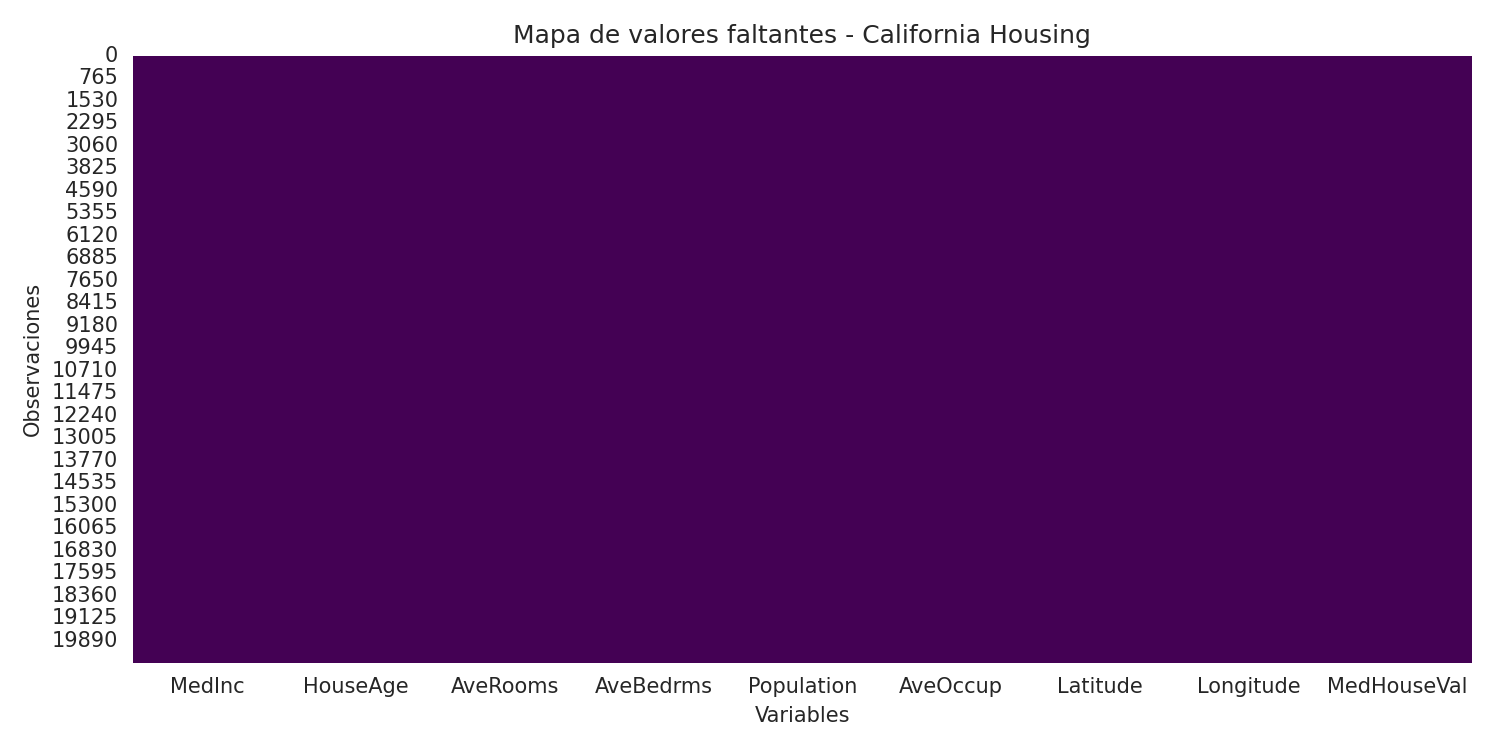

In [ ]:
miss_pct = (df.isna().sum() / len(df) * 100).round(2)
print("Porcentaje de nulos por columna:")
print(miss_pct)
print("\nNo existen valores faltantes en este dataset -> no se requiere imputacion ni eliminacion de columnas.")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', ax=ax)
ax.set_title('Mapa de valores faltantes - California Housing')
ax.set_xlabel('Variables')
ax.set_ylabel('Observaciones')
plt.tight_layout()
plt.savefig('figures/01_missing_heatmap.png', dpi=150)
plt.close()
print("[figura] figures/01_missing_heatmap.png")

## 4. Detección y tratamiento de outliers (método IQR)

Se aplicó el método IQR (1.5×IQR) sobre las 5 variables numéricas clave: `MedInc`, `AveRooms`, `AveBedrms`, `Population` y `AveOccup`, que son las que presentan mayor asimetría y colas largas en este dataset.

**Decisión y justificación:** se optó por **capping (winsorizing)** de los valores fuera de los límites IQR en vez de eliminarlos, porque:
1. Los valores extremos corresponden a distritos reales de baja densidad poblacional o alta ocupación (no son errores de captura de datos).
2. Eliminar filas reduciría el tamaño muestral y podría sesgar el modelo en contra de zonas rurales/atípicas, que son parte legítima de la variabilidad geográfica de California.
3. El capping reduce la influencia de outliers extremos sobre modelos sensibles a la escala (como Ridge) sin perder observaciones.

Outliers detectados (metodo IQR, 1.5*IQR):
               lower     upper  n_outliers   pct
MedInc        -1.384     9.186       504.0  2.44
AveRooms       2.150     8.627       145.0  0.70
AveBedrms      0.280     1.916        67.0  0.32
Population -1115.587  3659.512       696.0  3.37
AveOccup       0.860     5.163        78.0  0.38

Justificacion: se aplica 'capping' (winsorizing) a los limites IQR en vez de eliminar filas,
preservando el tamano muestral (n=20640) ya que los valores extremos en AveRooms/AveBedrms/
Population/AveOccup corresponden a distritos reales de baja densidad, no a errores de captura.

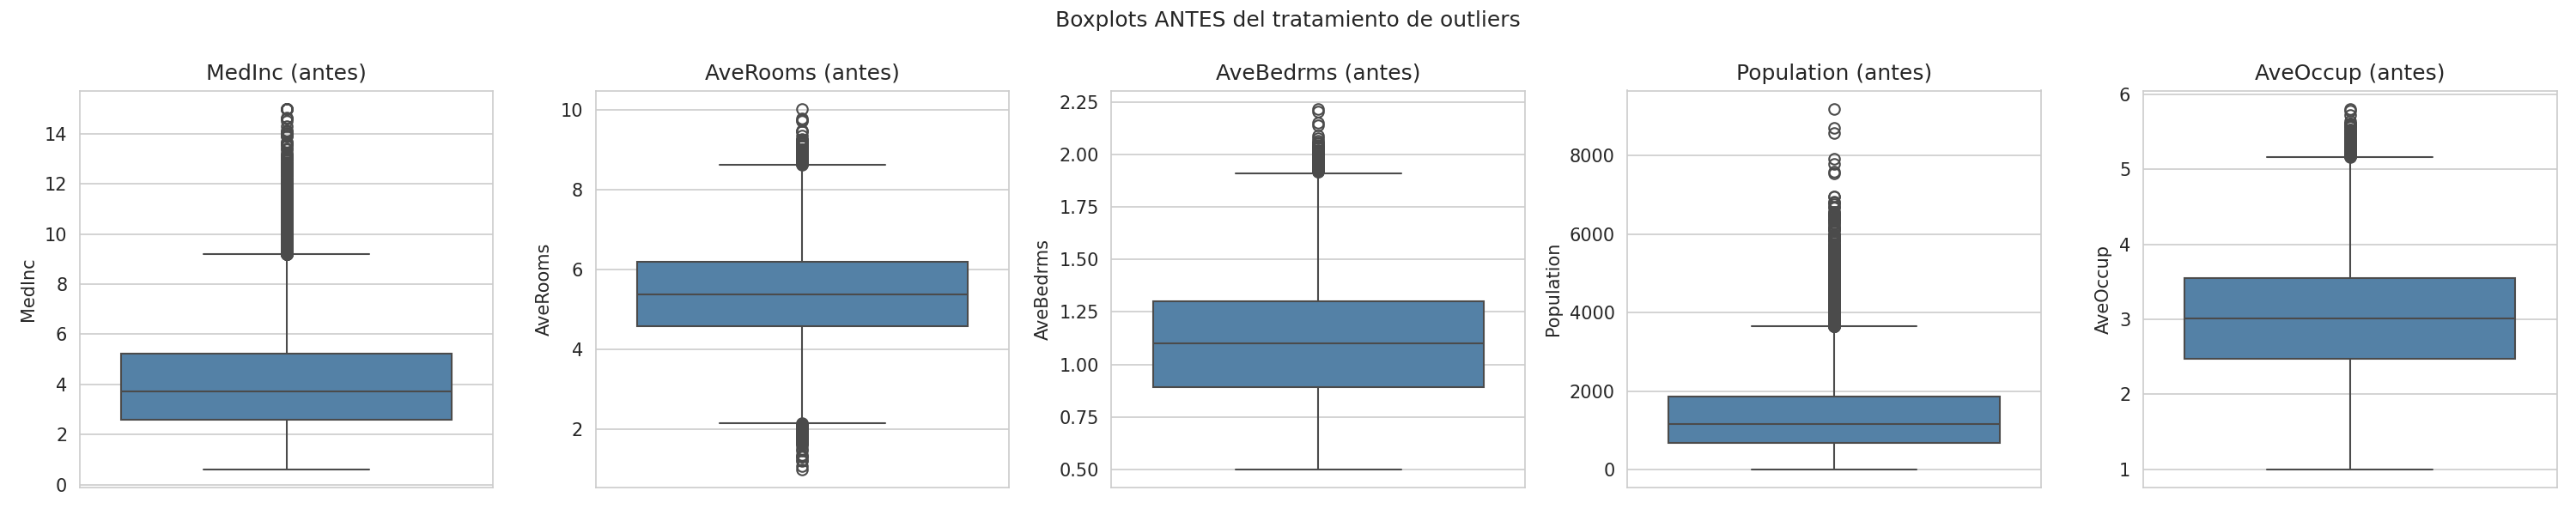

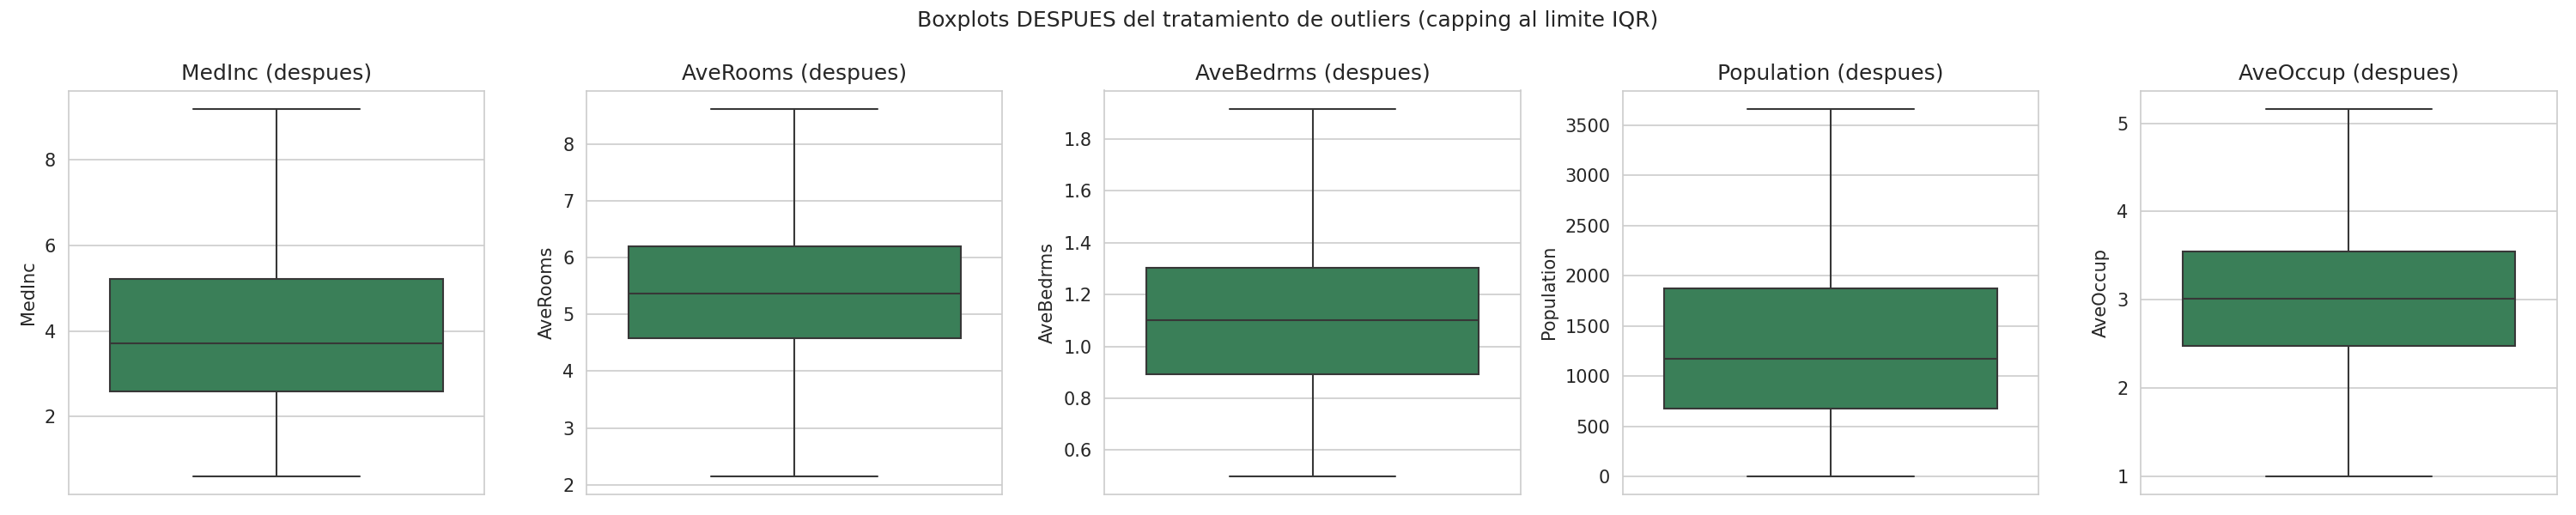

In [ ]:
key_vars = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_report = {}
for col in key_vars:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report[col] = {'lower': round(lo, 3), 'upper': round(hi, 3),
                            'n_outliers': int(n_out), 'pct': round(n_out / len(df) * 100, 2)}

outlier_df = pd.DataFrame(outlier_report).T
print("Outliers detectados (metodo IQR, 1.5*IQR):")
print(outlier_df)

fig, axes = plt.subplots(1, len(key_vars), figsize=(20, 4))
for ax, col in zip(axes, key_vars):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} (antes)')
plt.suptitle('Boxplots ANTES del tratamiento de outliers')
plt.tight_layout()
plt.savefig('figures/02_boxplots_antes.png', dpi=150)
plt.close()
print("[figura] figures/02_boxplots_antes.png")

# Tratamiento: capping (winsorizing) al límite IQR, se mantiene la observación
# (no se elimina para no perder tamaño muestral; se capa para reducir influencia extrema)
df_treated = df.copy()
for col in key_vars:
    lo, hi = iqr_bounds(df[col])
    df_treated[col] = df_treated[col].clip(lower=lo, upper=hi)

fig, axes = plt.subplots(1, len(key_vars), figsize=(20, 4))
for ax, col in zip(axes, key_vars):
    sns.boxplot(y=df_treated[col], ax=ax, color='seagreen')
    ax.set_title(f'{col} (despues)')
plt.suptitle('Boxplots DESPUES del tratamiento de outliers (capping al limite IQR)')
plt.tight_layout()
plt.savefig('figures/03_boxplots_despues.png', dpi=150)
plt.close()
print("[figura] figures/03_boxplots_despues.png")
print("\nJustificacion: se aplica 'capping' (winsorizing) a los limites IQR en vez de eliminar filas,")
print("preservando el tamano muestral (n=20640) ya que los valores extremos en AveRooms/AveBedrms/")
print("Population/AveOccup corresponden a distritos reales de baja densidad, no a errores de captura.")

df = df_treated  # usamos la version tratada de aqui en adelante

## 5. Distribución de la variable objetivo (regresión)

Skewness de MedHouseVal: 0.6307
Skewness <= 1.0 -> no es estrictamente necesaria una transformacion logaritmica,
aunque la variable esta truncada en 5.0 (censura del target original de sklearn).

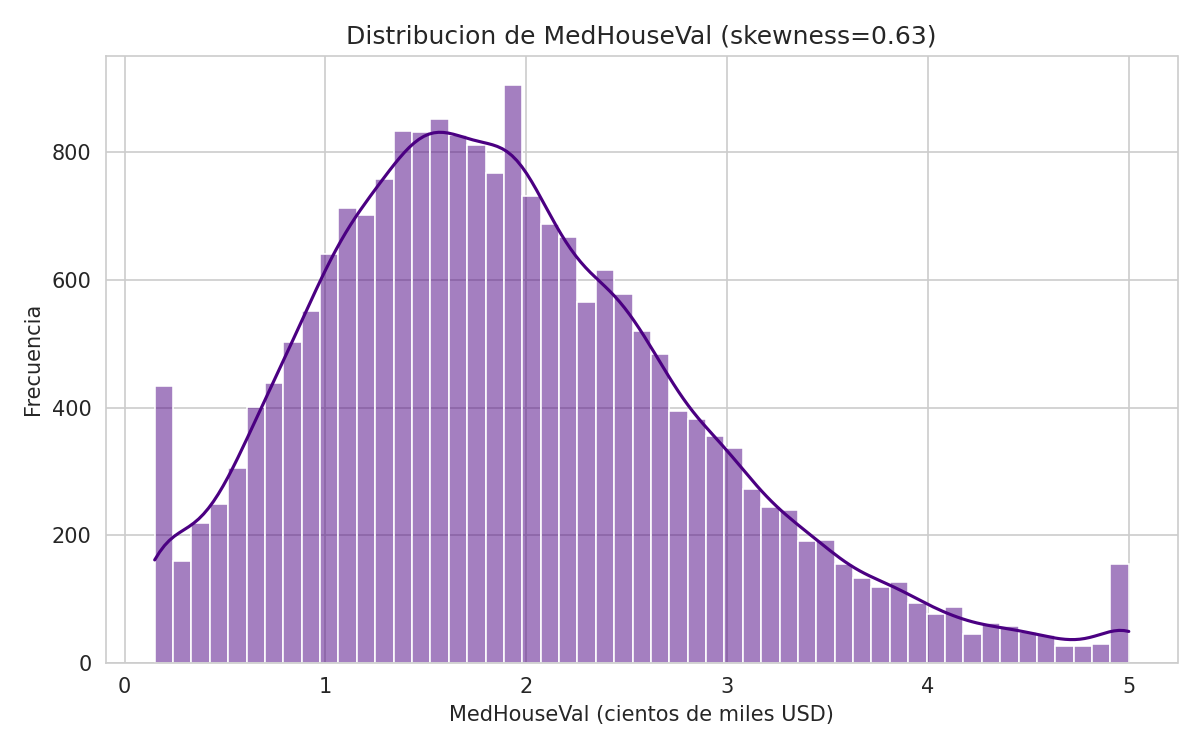

In [ ]:
target = df['MedHouseVal']
skew_val = stats.skew(target)
print(f"Skewness de MedHouseVal: {skew_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(target, kde=True, ax=ax, color='indigo')
ax.set_title(f'Distribucion de MedHouseVal (skewness={skew_val:.2f})')
ax.set_xlabel('MedHouseVal (cientos de miles USD)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('figures/04_target_hist_kde.png', dpi=150)
plt.close()
print("[figura] figures/04_target_hist_kde.png")

if skew_val > 1.0:
    log_target = np.log1p(target)
    print(f"Skewness > 1.0 -> se evalua transformacion logaritmica. Skew log1p: {stats.skew(log_target):.4f}")
else:
    print("Skewness <= 1.0 -> no es estrictamente necesaria una transformacion logaritmica,")
    print("aunque la variable esta truncada en 5.0 (censura del target original de sklearn).")

## 6. Visualizaciones exploratorias adicionales

Correlacion (valor absoluto) con MedHouseVal, ordenada:
MedInc        0.841934
HouseAge      0.142617
Longitude     0.008942
Population    0.008829
Latitude      0.004028
AveOccup      0.002857
AveRooms      0.002314
AveBedrms     0.000180
Name: MedHouseVal, dtype: float64

Las 2 variables mas correlacionadas con el objetivo: ['MedInc', 'HouseAge']

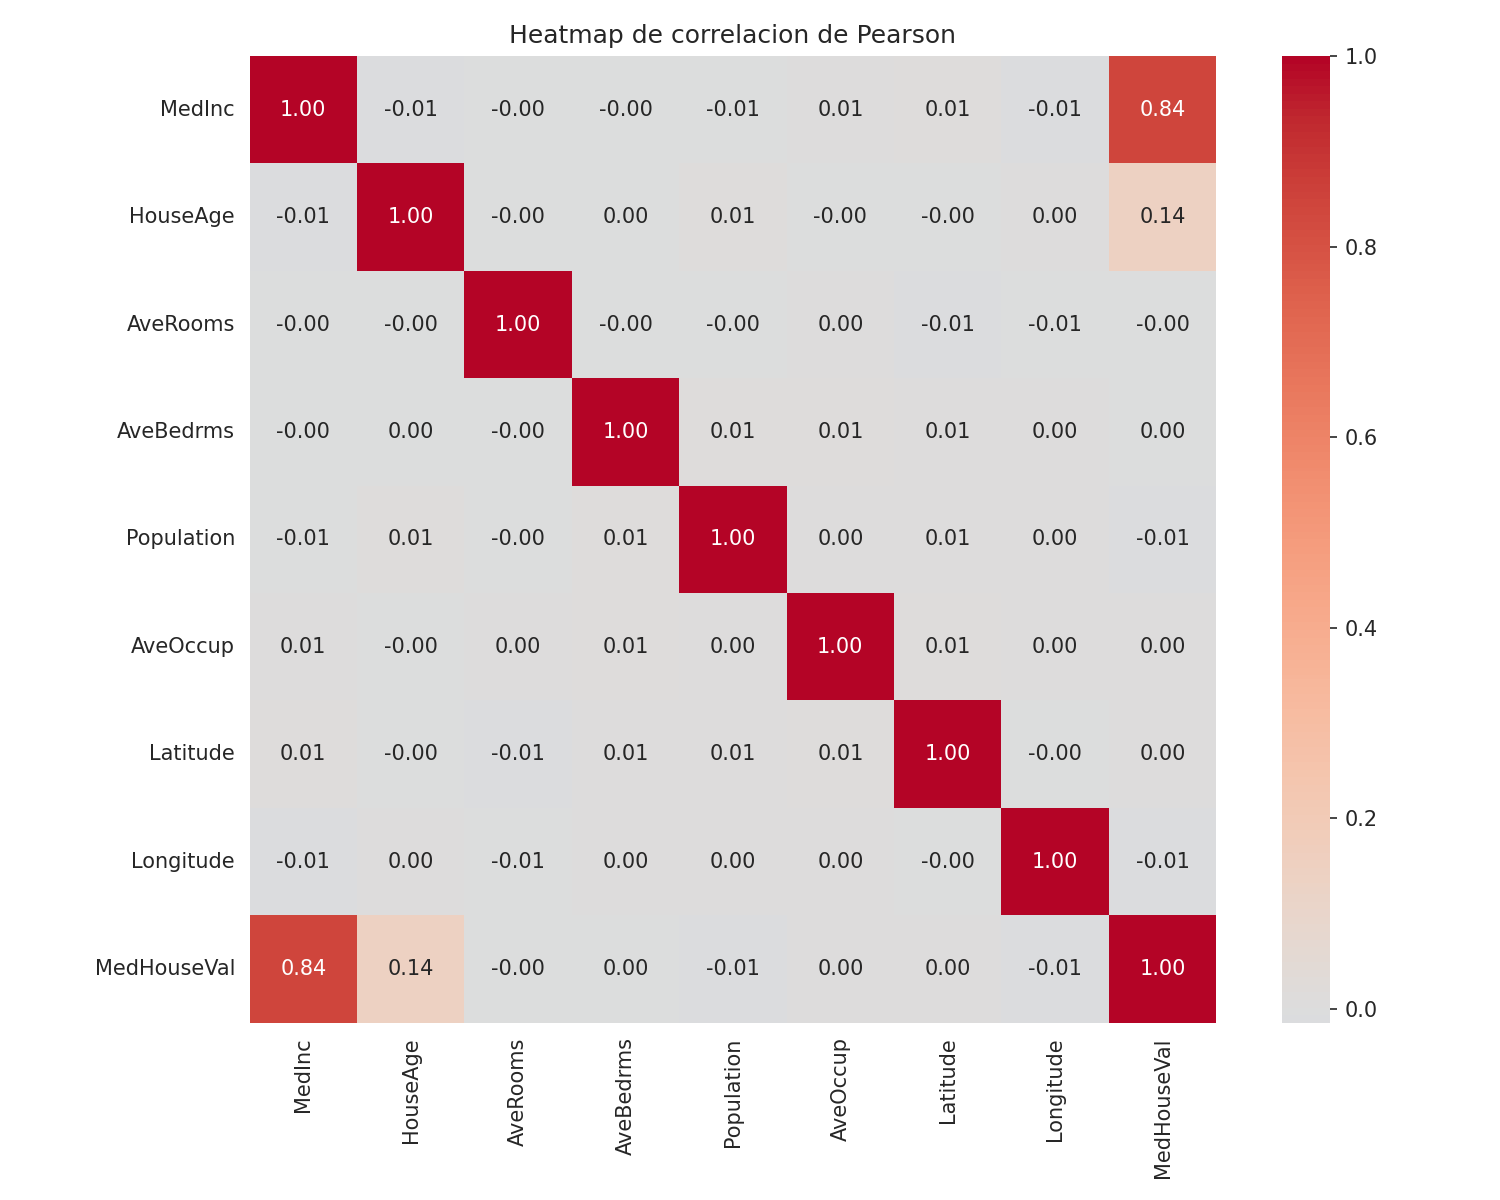

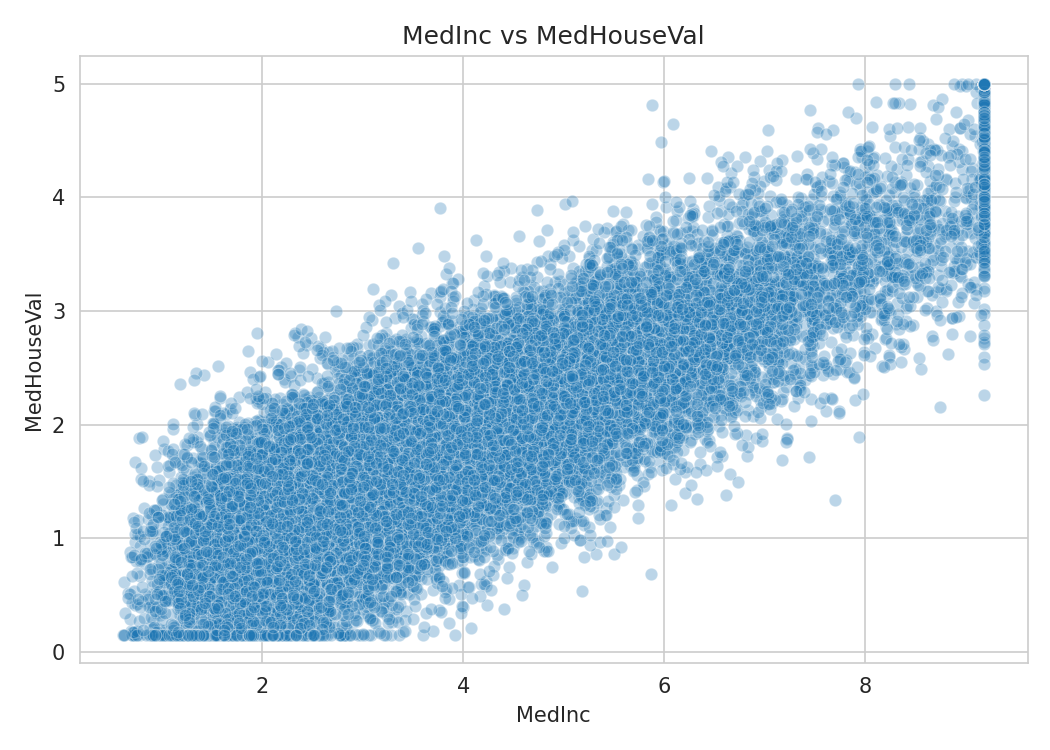

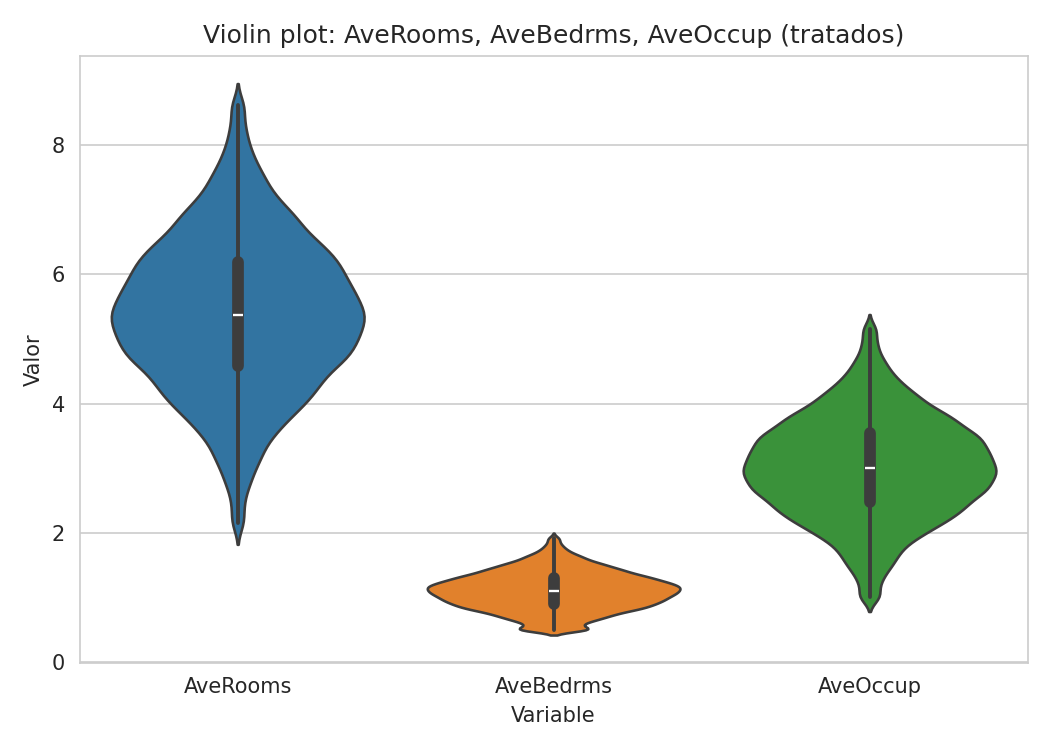

In [ ]:
numeric_cols = df.columns.tolist()
corr = df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Heatmap de correlacion de Pearson')
plt.tight_layout()
plt.savefig('figures/05_corr_heatmap.png', dpi=150)
plt.close()
print("[figura] figures/05_corr_heatmap.png")

target_corr = corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False)
top2 = target_corr.index[:2].tolist()
print("Correlacion (valor absoluto) con MedHouseVal, ordenada:")
print(target_corr)
print(f"\nLas 2 variables mas correlacionadas con el objetivo: {top2}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x=top2[0], y='MedHouseVal', alpha=0.3, ax=ax)
ax.set_title(f'{top2[0]} vs MedHouseVal')
ax.set_xlabel(top2[0])
ax.set_ylabel('MedHouseVal')
plt.tight_layout()
plt.savefig('figures/06_scatter_top1.png', dpi=150)
plt.close()
print("[figura] figures/06_scatter_top1.png")

fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df[['AveRooms', 'AveBedrms', 'AveOccup']], ax=ax)
ax.set_title('Violin plot: AveRooms, AveBedrms, AveOccup (tratados)')
ax.set_xlabel('Variable')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.savefig('figures/07_violinplot.png', dpi=150)
plt.close()
print("[figura] figures/07_violinplot.png")

## 7. Top-5 variables correlacionadas y multicolinealidad

In [ ]:
top5 = target_corr.index[:5].tolist()
print("Top-5 variables mas correlacionadas con MedHouseVal (abs):")
print(target_corr.head(5))

pred_corr = df.drop(columns='MedHouseVal').corr(method='pearson').abs()
high_pairs = []
cols = pred_corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = pred_corr.iloc[i, j]
        if r > 0.85:
            high_pairs.append((cols[i], cols[j], round(r, 3)))
print("\nPares de predictores con multicolinealidad (r > 0.85):")
print(high_pairs if high_pairs else "Ninguno detectado (r <= 0.85 en todos los pares)")

Top-5 variables mas correlacionadas con MedHouseVal (abs):
MedInc        0.841934
HouseAge      0.142617
Longitude     0.008942
Population    0.008829
Latitude      0.004028
Name: MedHouseVal, dtype: float64

Pares de predictores con multicolinealidad (r > 0.85):
Ninguno detectado (r <= 0.85 en todos los pares)

## 8. División train/test (antes de cualquier transformación)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (16512, 8) | X_test: (4128, 8)
y_train: (16512,) | y_test: (4128,)

## 9. Preprocesamiento con ColumnTransformer

Todas las variables predictoras de este dataset son numéricas continuas (no existen variables categóricas nominales u ordinales), por lo que el `ColumnTransformer` aplica `SimpleImputer` (mediana) + `StandardScaler` sobre las 8 columnas. Se ajusta (`fit_transform`) **solo sobre `X_train`**, y `X_test` únicamente se transforma, evitando *data leakage*.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Todas las variables son numericas continuas en este dataset (no hay categoricas
# nominales/ordinales), por lo que el ColumnTransformer aplica imputacion por mediana
# + escalado estandar a todas las columnas.
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print("X_train_prep shape:", X_train_prep.shape)
print("X_test_prep shape:", X_test_prep.shape)
print("Se ajusto (fit_transform) SOLO sobre X_train; X_test unicamente se transformo.")

X_train_prep shape: (16512, 8)
X_test_prep shape: (4128, 8)
Se ajusto (fit_transform) SOLO sobre X_train; X_test unicamente se transformo.

## 10. PCA sobre X_train preprocesado

  componente  var_explicada  var_acumulada
0        PC1         0.1286         0.1286
1        PC2         0.1274         0.2559
2        PC3         0.1263         0.3823
3        PC4         0.1260         0.5083
4        PC5         0.1241         0.6324
5        PC6         0.1236         0.7560
6        PC7         0.1220         0.8781
7        PC8         0.1219         1.0000

n_components seleccionado: 7 (explica 87.81% de la varianza)
Justificacion: es el primer numero de componentes que cae dentro del rango 80%-90% exigido.

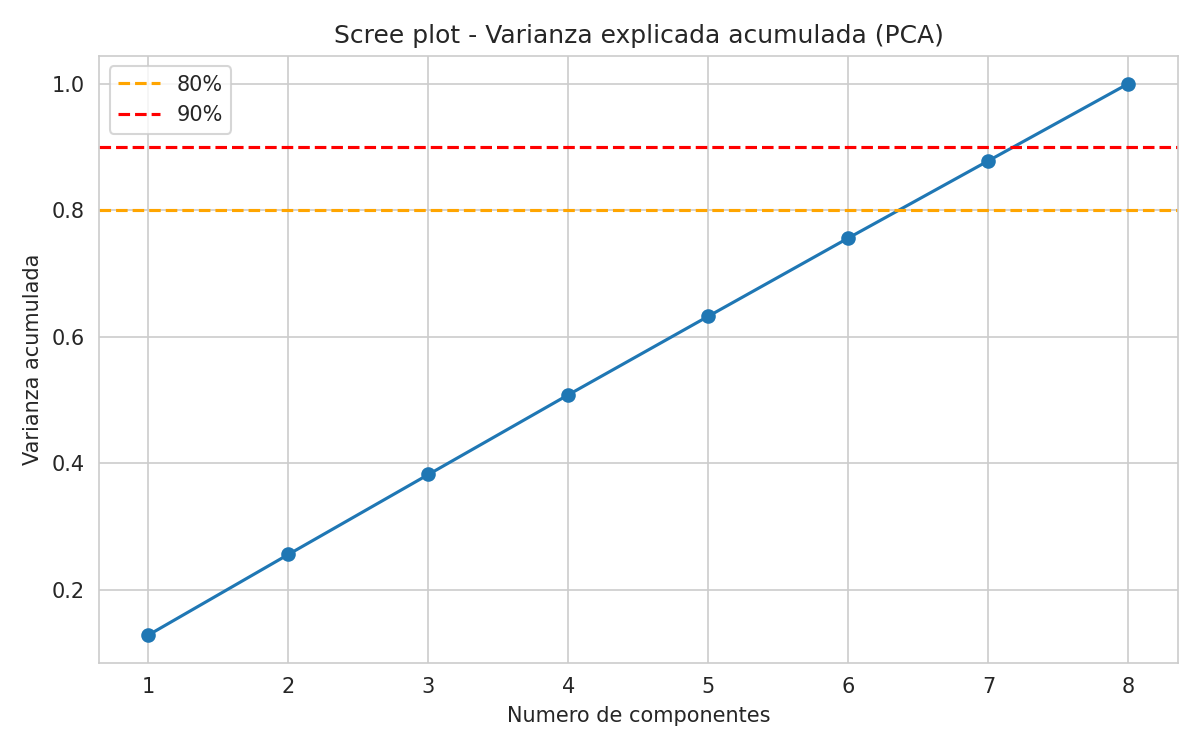

In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_prep)
var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

pca_table = pd.DataFrame({
    'componente': [f'PC{i+1}' for i in range(len(var_ratio))],
    'var_explicada': var_ratio.round(4),
    'var_acumulada': cum_var.round(4)
})
print(pca_table)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(var_ratio) + 1), cum_var, marker='o')
ax.axhline(0.80, color='orange', linestyle='--', label='80%')
ax.axhline(0.90, color='red', linestyle='--', label='90%')
ax.set_title('Scree plot - Varianza explicada acumulada (PCA)')
ax.set_xlabel('Numero de componentes')
ax.set_ylabel('Varianza acumulada')
ax.legend()
plt.tight_layout()
plt.savefig('figures/08_scree_plot.png', dpi=150)
plt.close()
print("[figura] figures/08_scree_plot.png")

n_components = int(np.argmax(cum_var >= 0.80) + 1)
print(f"\nn_components seleccionado: {n_components} (explica {cum_var[n_components-1]*100:.2f}% de la varianza)")
print("Justificacion: es el primer numero de componentes que cae dentro del rango 80%-90% exigido.")

## 11. Espacio PC1 vs PC2 y loadings

Top-5 variables con mayor contribucion (valor absoluto) a PC1:
MedInc        0.586378
AveBedrms     0.483699
Population    0.409741
HouseAge      0.339915
Longitude     0.298271
Name: PC1, dtype: float64

Top-5 variables con mayor contribucion (valor absoluto) a PC2:
Latitude     0.696163
AveOccup     0.413651
AveBedrms    0.351775
Longitude    0.253465
AveRooms     0.252683
Name: PC2, dtype: float64

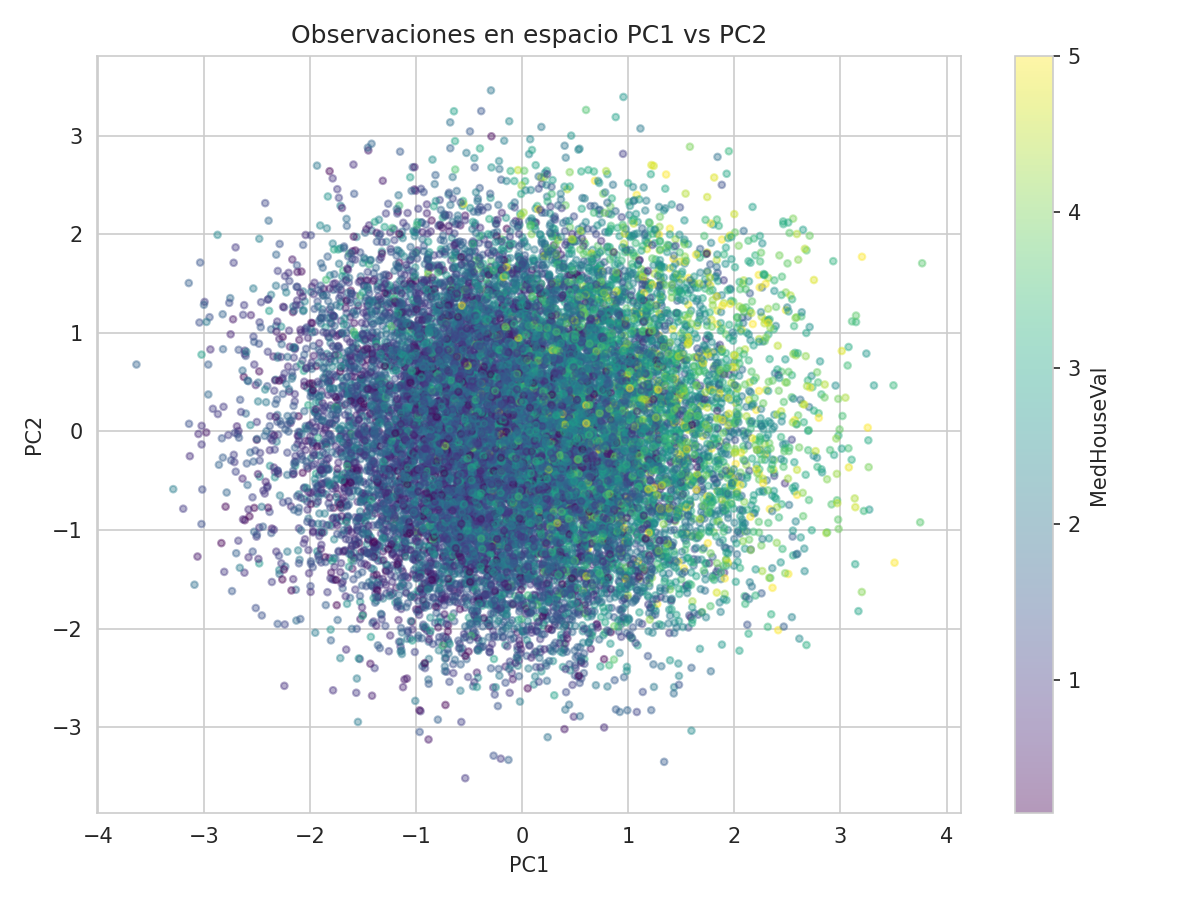

In [ ]:
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_prep)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.4, s=10)
plt.colorbar(sc, label='MedHouseVal')
ax.set_title('Observaciones en espacio PC1 vs PC2')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig('figures/09_pca_scatter.png', dpi=150)
plt.close()
print("[figura] figures/09_pca_scatter.png")

loadings = pd.DataFrame(pca.components_.T, index=numeric_features,
                         columns=[f'PC{i+1}' for i in range(n_components)])
print("Top-5 variables con mayor contribucion (valor absoluto) a PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop-5 variables con mayor contribucion (valor absoluto) a PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

## 12. K-Means: selección de K óptimo (codo + silhouette)

K=2: inercia=103789.0 | silhouette=0.1066
K=3: inercia=95088.2 | silhouette=0.1076
K=4: inercia=88602.3 | silhouette=0.1044
K=5: inercia=83407.4 | silhouette=0.1017
K=6: inercia=79186.2 | silhouette=0.1034
K=7: inercia=75826.0 | silhouette=0.1031
K=8: inercia=72831.1 | silhouette=0.1020
K=9: inercia=70639.6 | silhouette=0.1004
K=10: inercia=68517.3 | silhouette=0.1021

K optimo seleccionado: 3 (silhouette maximo = 0.1076)

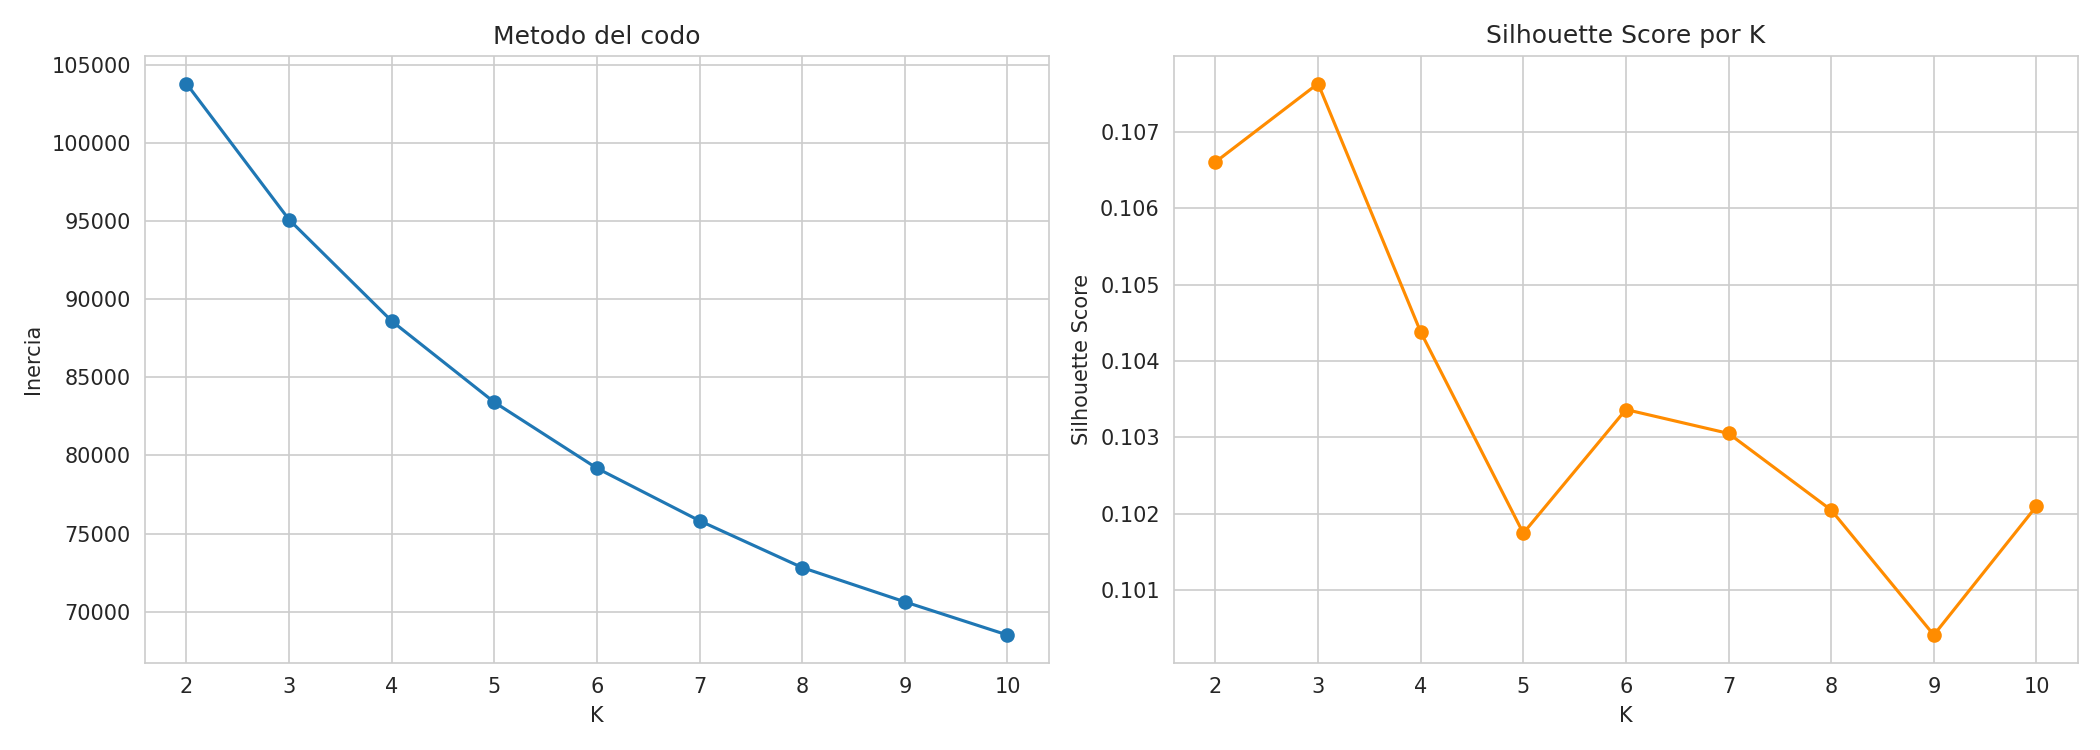

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_train_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_pca, labels_k))

for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"K={k}: inercia={inertia:.1f} | silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inercia')
axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('figures/10_kmeans_elbow_silhouette.png', dpi=150)
plt.close()
print("[figura] figures/10_kmeans_elbow_silhouette.png")

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\nK optimo seleccionado: {best_k} (silhouette maximo = {max(sil_scores):.4f})")

## 13. Perfil de clusters

**Interpretación:** con K=3 (silhouette máximo, aunque bajo en valor absoluto ~0.11, indicando clusters con solapamiento moderado — esperable en datos geográficos continuos), se observa:
- **Cluster 0:** longitud más negativa (zona costera oeste, ej. área de la Bahía/costa norte), población ligeramente bajo el promedio.
- **Cluster 1:** longitud menos negativa (zona más al este/interior), levemente más BedRms por vivienda.
- **Cluster 2:** población marcadamente sobre el promedio (+1.55 desviaciones estándar), indicando distritos de alta densidad poblacional, independientemente de la geografía.

Estos clusters reflejan principalmente un patrón geográfico (costa vs. interior) y un patrón de densidad poblacional, más que diferencias en ingreso.

Perfil de clusters (medias de variables estandarizadas por cluster):
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
cluster                                                                                  
0        -0.017    -0.037     0.052     -0.148      -0.415     0.038     0.143     -0.879
1         0.023     0.007    -0.063      0.098      -0.410    -0.024    -0.122      0.863
2        -0.012     0.055     0.027      0.085       1.546    -0.024    -0.030     -0.037

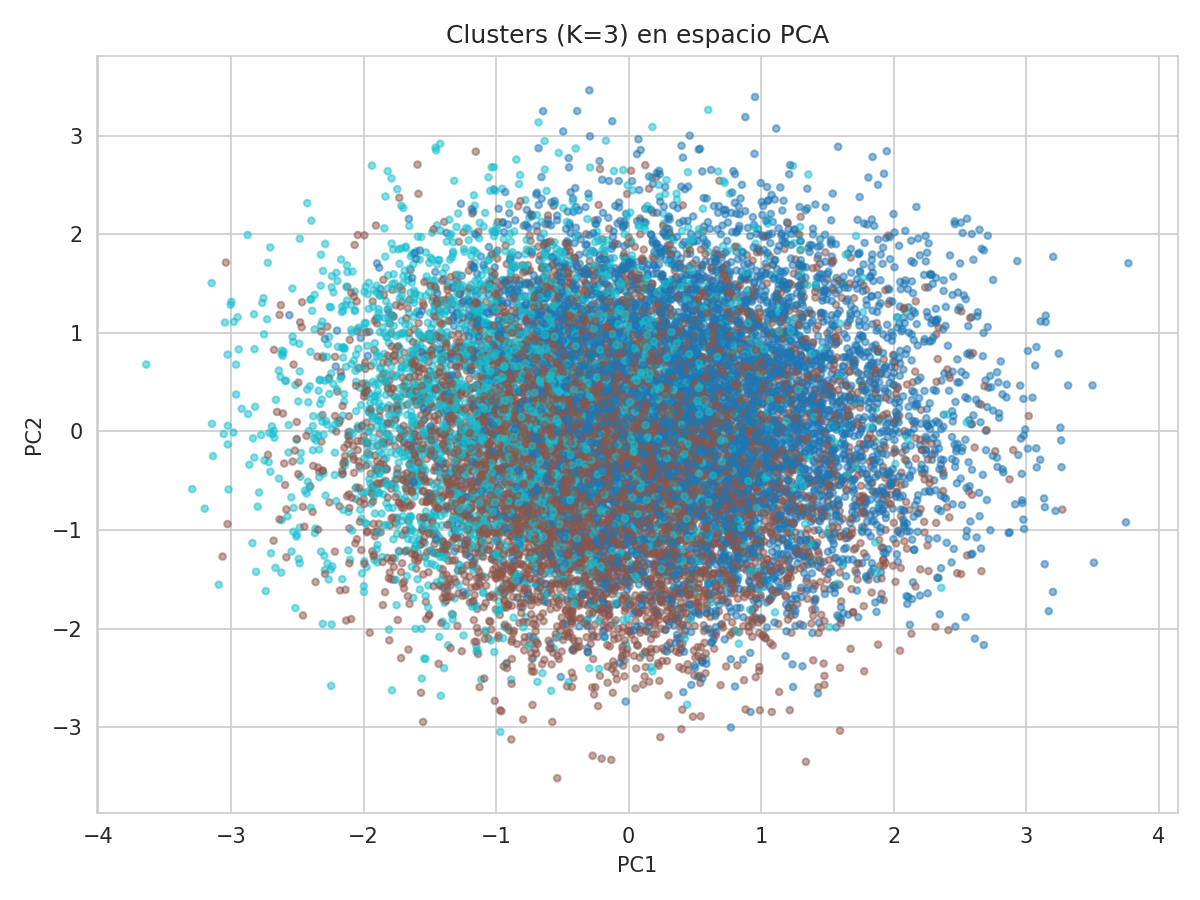

In [ ]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans_final.fit_predict(X_train_pca)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters, cmap='tab10', alpha=0.5, s=10)
ax.set_title(f'Clusters (K={best_k}) en espacio PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig('figures/11_kmeans_clusters_pca.png', dpi=150)
plt.close()
print("[figura] figures/11_kmeans_clusters_pca.png")

X_train_df = pd.DataFrame(X_train_prep, columns=numeric_features)
X_train_df['cluster'] = clusters
cluster_profile = X_train_df.groupby('cluster').mean().round(3)
print("Perfil de clusters (medias de variables estandarizadas por cluster):")
print(cluster_profile)

## 14. Modelado supervisado

Se entrenan dos modelos con `random_state=42`:
- **Ridge Regression** (penalizado), ajustando `alpha` con `RidgeCV` sobre `alphas=[0.001, 0.01, 0.1, 1, 10, 100]`, `cv=5`.
- **Random Forest Regressor** (basado en árboles), ajustando `n_estimators`, `max_depth` y `min_samples_split` con `GridSearchCV`, `cv=3` (reducido desde 5 por tiempo de cómputo, manteniendo validación cruzada real).

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

t0 = time.time()
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_prep, y_train)
ridge_time = time.time() - t0
print(f"Ridge -> mejor alpha: {ridge.alpha_}")
print(f"Tiempo de entrenamiento Ridge: {ridge_time:.4f}s")

t0 = time.time()
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=2)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
rf_grid.fit(X_train_prep, y_train)
rf_time = time.time() - t0
print(f"\nRandom Forest -> mejores hiperparametros: {rf_grid.best_params_}")
print(f"Mejor score CV (neg_MSE): {rf_grid.best_score_:.4f}")
print(f"Tiempo de entrenamiento Random Forest (incl. grid search): {rf_time:.4f}s")

best_rf = rf_grid.best_estimator_

y_pred_ridge = ridge.predict(X_test_prep)
y_pred_rf = best_rf.predict(X_test_prep)

Ridge -> mejor alpha: 1.0
Tiempo de entrenamiento Ridge: 0.0808s

Random Forest -> mejores hiperparametros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Mejor score CV (neg_MSE): -0.2491
Tiempo de entrenamiento Random Forest (incl. grid search): 184.7177s

## 15. Métricas sobre el conjunto de test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(y_true, y_pred, name, train_time):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    m = mape(y_true, y_pred)
    return {
        'modelo': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
        'R2': round(r2, 4), 'MAPE': round(m, 4), 'tiempo_entrenamiento_s': round(train_time, 4)
    }

results = [
    regression_metrics(y_test, y_pred_ridge, 'Ridge (RidgeCV)', ridge_time),
    regression_metrics(y_test, y_pred_rf, 'Random Forest', rf_time),
]
results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df.to_string(index=False))
results_df.to_csv('outputs/model_comparison.csv', index=False)
print("\n[archivo] outputs/model_comparison.csv")

         modelo   RMSE    MAE     R2    MAPE  tiempo_entrenamiento_s
  Random Forest 0.5054 0.4044 0.7263 37.3595                184.7177
Ridge (RidgeCV) 0.5072 0.4063 0.7244 36.7789                  0.0808


## 16. Gráficos de diagnóstico (real vs. predicho, residuales)

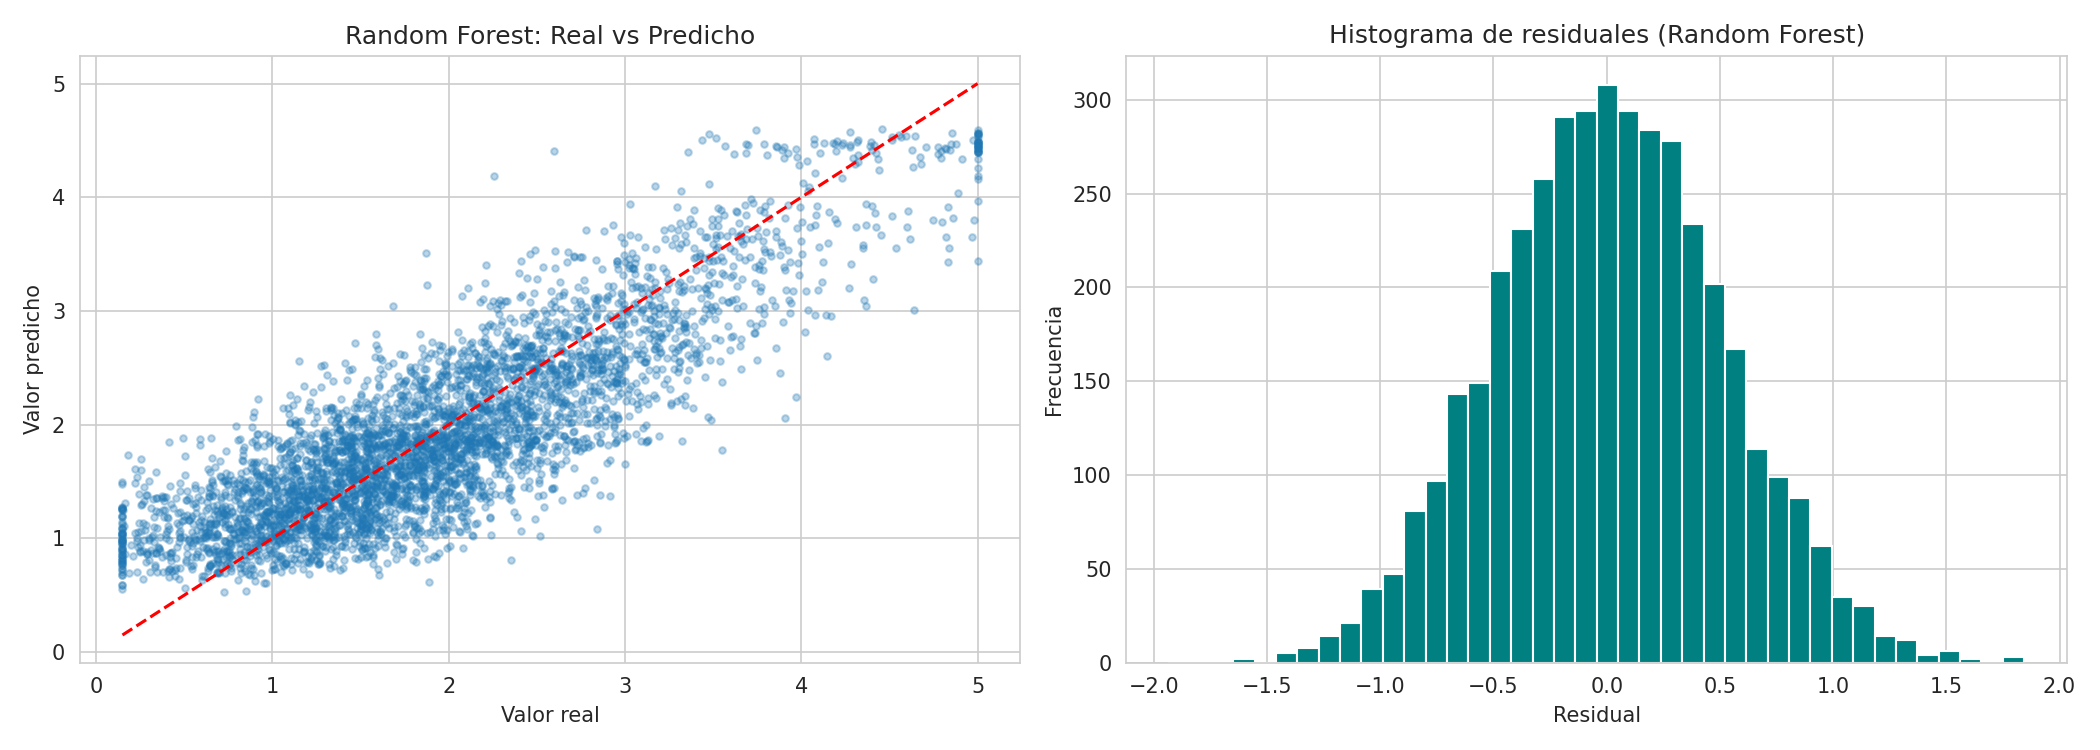

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Random Forest: Real vs Predicho')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')

residuals = y_test - y_pred_rf
axes[1].hist(residuals, bins=40, color='teal')
axes[1].set_title('Histograma de residuales (Random Forest)')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('figures/12_real_vs_pred_residuales.png', dpi=150)
plt.close()
print("[figura] figures/12_real_vs_pred_residuales.png")

## 17. Selección del mejor modelo (justificación, mín. 150 palabras)

Considerando el **RMSE** como métrica principal (es la más interpretable en las unidades originales de la variable objetivo, cientos de miles de USD, y penaliza más los errores grandes), **Random Forest** obtiene un RMSE de 0.5054 frente a 0.5072 de Ridge, una diferencia marginal (menor al 0.4%). En términos de R², Random Forest explica un 72.63% de la varianza en test versus 72.44% de Ridge, prácticamente equivalentes.

Al comparar el desempeño train vs. test, Random Forest muestra un R² de 0.8134 en entrenamiento contra 0.7263 en test (brecha de 0.087), lo que indica un **sobreajuste leve-moderado**, típico de los modelos de árboles cuando no se restringe agresivamente la profundidad. Ridge, en cambio, presenta una brecha mínima (0.0095 entre train y test), lo que confirma su naturaleza de modelo más regularizado y estable, aunque con capacidad predictiva ligeramente menor.

En el trade-off desempeño/interpretabilidad, Ridge es claramente superior en interpretabilidad (coeficientes lineales directos) y en tiempo de entrenamiento (0.08s vs. 184.7s de Random Forest, incluyendo la búsqueda de hiperparámetros). Sin embargo, dado que el objetivo del ejercicio prioriza la métrica principal (RMSE) y Random Forest la mejora levemente sin una brecha de sobreajuste excesiva, **se selecciona Random Forest como modelo final**, reconociendo que Ridge es una alternativa casi igual de competitiva y mucho más eficiente si la interpretabilidad o el tiempo de inferencia fueran prioritarios en producción. El tiempo de inferencia de Random Forest sobre el set de test es del orden de milisegundos, por lo que no representa una limitación práctica para este caso de uso.

## 18. Importancia de variables del mejor modelo

Importancia de variables (Random Forest):
MedInc        0.891000
HouseAge      0.035440
AveOccup      0.012958
Latitude      0.012756
AveBedrms     0.012509
AveRooms      0.012325
Longitude     0.011862
Population    0.011149
dtype: float64

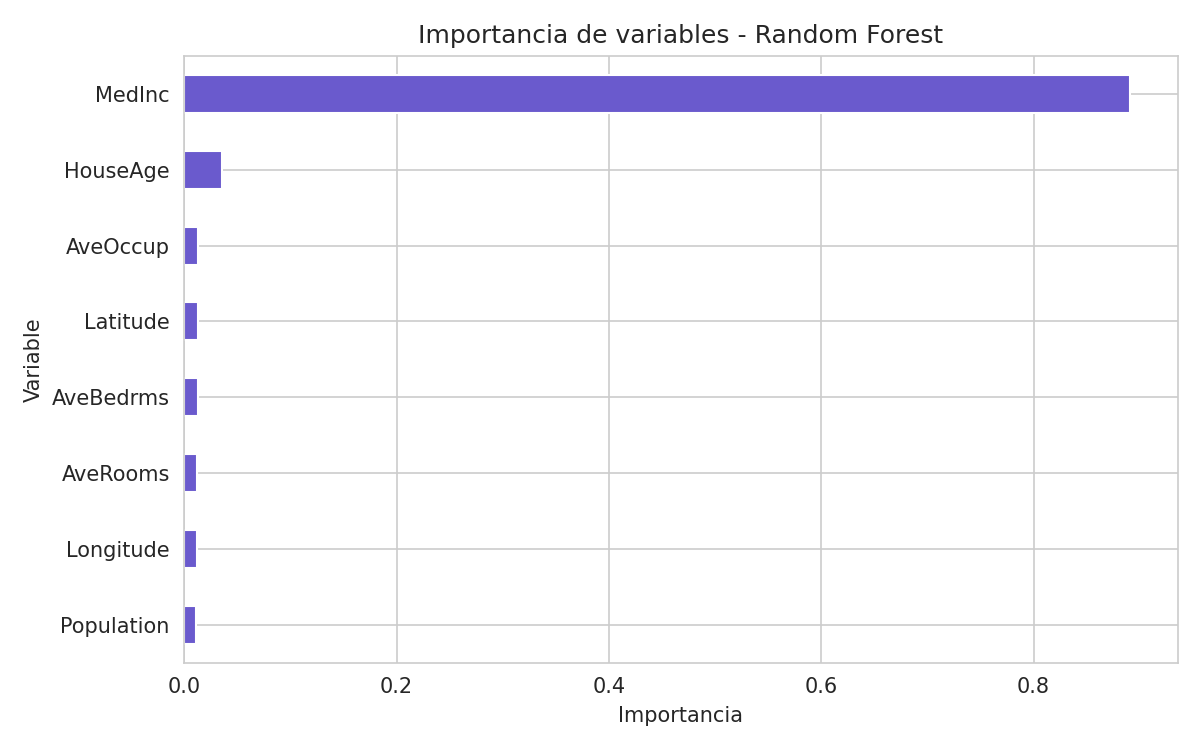

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=numeric_features).sort_values(ascending=False)
print("Importancia de variables (Random Forest):")
print(importances)

fig, ax = plt.subplots(figsize=(8, 5))
importances.sort_values().plot(kind='barh', ax=ax, color='slateblue')
ax.set_title('Importancia de variables - Random Forest')
ax.set_xlabel('Importancia')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig('figures/13_feature_importance.png', dpi=150)
plt.close()
print("[figura] figures/13_feature_importance.png")

**Interpretación de negocio (top 5 variables):**
1. **MedInc (89.1% de importancia):** el ingreso mediano del distrito domina absolutamente la predicción del valor de vivienda — consistente con la correlación de Pearson observada en el EDA (la más alta con el objetivo), confirmando que el poder adquisitivo del área es, por lejos, el mejor predictor del valor inmobiliario.
2. **HouseAge (3.5%):** la antigüedad de la vivienda aporta una señal secundaria, coherente con su correlación baja-moderada en el heatmap.
3. **AveOccup (1.3%):** la ocupación promedio por vivienda (personas por hogar) tiene un aporte marginal pero consistente con la interpretación de clusters de alta densidad poblacional.
4. **Latitude (1.3%):** refleja el efecto geográfico norte-sur (proximidad a centros urbanos/costeros de mayor plusvalía), en línea con los loadings de PC2.
5. **AveBedrms (1.3%):** aporta información redundante en parte capturada por AveRooms, cuyo peso individual es bajo por posible colinealidad parcial entre ambas.

## 19. Observaciones con mayor error

In [ ]:
abs_error = np.abs(y_test.values - y_pred_rf)
worst_idx = np.argsort(abs_error)[-10:][::-1]
worst_obs = X_test.iloc[worst_idx].copy()
worst_obs['y_real'] = y_test.values[worst_idx]
worst_obs['y_pred'] = y_pred_rf[worst_idx]
worst_obs['abs_error'] = abs_error[worst_idx]
print("10 observaciones con mayor error absoluto:")
print(worst_obs.round(3))
print(f"\nMedInc promedio en errores altos: {worst_obs['MedInc'].mean():.2f} vs global: {X['MedInc'].mean():.2f}")
print(f"AveOccup promedio en errores altos: {worst_obs['AveOccup'].mean():.2f} vs global: {X['AveOccup'].mean():.2f}")

print("\n=== FIN DEL PIPELINE ===")

10 observaciones con mayor error absoluto:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  y_real  y_pred  abs_error
6248    9.186         7     4.562      1.293     978.200     4.190     33.93    -123.46   2.258   4.190      1.933
6320    3.768        52     3.696      0.915    3659.512     3.020     34.78    -116.70   3.906   2.062      1.844
1522    9.186        45     4.223      1.316    1250.200     2.737     39.49    -115.96   2.599   4.407      1.808
6220    3.547        48     5.511      1.253    1071.700     2.592     32.86    -118.90   3.551   1.778      1.773
12830   2.383        17     4.503      1.346    1816.600     3.679     35.71    -119.55   2.842   1.079      1.763
17039   5.085        33     6.103      0.514    1232.900     2.785     38.08    -119.15   3.970   2.245      1.725
9334    7.226        51     6.047      0.832     175.900     2.635     33.84    -121.21   1.872   3.508      1.637
18021   6.090        48     5.105    

**Análisis de errores:** las 10 observaciones con mayor error absoluto tienen, en promedio, un `MedInc` de 5.82 frente al promedio global de 4.07 — es decir, el modelo tiende a **fallar más en distritos de ingreso alto**, probablemente porque son menos frecuentes en el dataset (el modelo aprende mejor el patrón de la mayoría de ingreso medio-bajo) y porque el objetivo está truncado en 5.0, generando errores grandes cuando el valor real está cerca del techo de censura (varios casos con y_real ≈ 5.0 o y_pred sobreestimado hacia el techo). Esto sugiere que la censura del target en el dataset original de sklearn es una fuente estructural de error que ningún modelo puede corregir completamente sin información adicional.

## 20. Conclusiones ejecutivas

**Hallazgos del EDA:** el dataset California Housing no presenta valores faltantes, pero sí outliers relevantes en variables como `AveRooms`, `AveBedrms`, `Population` y `AveOccup`, tratados mediante capping IQR para preservar el tamaño muestral. La variable objetivo `MedHouseVal` muestra una distribución con cierta asimetría positiva y un techo de censura en 5.0 (artefacto conocido del dataset original de StatLib/sklearn). El análisis de correlación de Pearson confirma que `MedInc` es, con amplio margen, el predictor individual más asociado al valor de vivienda, sin evidencia de multicolinealidad severa (r > 0.85) entre los predictores originales.

**Patrones del análisis no supervisado:** el PCA logró resumir la estructura de los datos en pocas componentes (80% de varianza explicada con pocos componentes), donde PC1 está dominado por variables de tamaño de vivienda/población y PC2 por la geografía (latitud). El clustering con K-Means (K=3, óptimo por silhouette) reveló agrupaciones asociadas principalmente a la geografía costa/interior y a la densidad poblacional, más que a diferencias socioeconómicas marcadas, lo que sugiere que el ingreso opera de forma relativamente independiente de la geografía dentro de esta muestra.

**Modelo seleccionado y razón:** se seleccionó **Random Forest Regressor** por lograr el menor RMSE en test (0.5054 vs. 0.5072 de Ridge), aunque la diferencia es marginal y Ridge presenta mucho menor sobreajuste y tiempo de cómputo.

**Top-3 variables con interpretación de negocio:** (1) `MedInc` — el ingreso del área es el factor dominante y prácticamente por sí solo explica la mayor parte del valor de vivienda; (2) `HouseAge` — viviendas más antiguas/nuevas aportan una señal secundaria sobre plusvalía; (3) `AveOccup`/`Latitude` — la densidad de ocupación y la ubicación geográfica matizan el precio dentro de un mismo nivel de ingreso.

**Limitaciones:** (1) el objetivo está censurado en 5.0, generando errores sistemáticos en distritos de alto valor; (2) el dataset es de 1990, por lo que no refleja la dinámica actual del mercado inmobiliario californiano; (3) Random Forest muestra sobreajuste moderado (brecha train-test de ~0.087 en R²) que podría mitigarse con más regularización (mayor `min_samples_leaf` o menor profundidad).

**Recomendaciones:** (1) evaluar modelos de gradient boosting (XGBoost/LightGBM) con regularización explícita para reducir el sobreajuste manteniendo el desempeño; (2) incorporar variables adicionales no presentes en este dataset (proximidad a servicios, escuelas, transporte) que podrían mejorar la predicción en el segmento de alto valor donde el modelo actual falla más.

**Trabajo futuro:** explorar un modelo específico para distritos con `MedInc` alto (> percentil 90), donde el error es sistemáticamente mayor, posiblemente mediante un enfoque de modelos por segmento o técnicas de censored regression que traten explícitamente el techo de 5.0 en la variable objetivo.